In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [3]:
DATA_PATH = "../data"

ratings = pd.read_csv(os.path.join(DATA_PATH, "ratings.csv"), sep=",")
movies = pd.read_csv(os.path.join(DATA_PATH, "movies.csv"), sep=",")

print(ratings.shape)
print(movies.shape)
ratings.head()

(32000204, 4)
(87585, 3)


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [4]:
movies.head(20)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [5]:
ratings.describe(include="all")

,userId,movieId,rating,timestamp
count,3.200020e+07,3.200020e+07,3.200020e+07,3.200020e+07
mean,1.002785e+05,2.931861e+04,3.540396e+00,1.275241e+09
std,5.794905e+04,5.095816e+04,1.058986e+00,2.561630e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,5.005300e+04,1.233000e+03,3.000000e+00,1.051012e+09
50%,1.002970e+05,3.452000e+03,3.500000e+00,1.272622e+09
75%,1.504510e+05,4.419900e+04,4.000000e+00,1.503158e+09
max,2.009480e+05,2.927570e+05,5.000000e+00,1.697164e+09


In [6]:
ratings.info()
print("\nBraki w kolumnach:\n", ratings.isna().sum())
print("\nDuplikaty w ratings:", ratings.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 976.6 MB

Braki w kolumnach:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Duplikaty w ratings: 0


In [7]:
movies.info()
print("\nBraki w kolumnach:\n", movies.isna().sum())
print("\nDuplikaty w movies:", movies.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  87585 non-null  int64 
 1   title    87585 non-null  object
 2   genres   87585 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB

Braki w kolumnach:
 movieId    0
title      0
genres     0
dtype: int64

Duplikaty w movies: 0


Text(0.5, 1.0, 'Rozkład ocen (rating)')

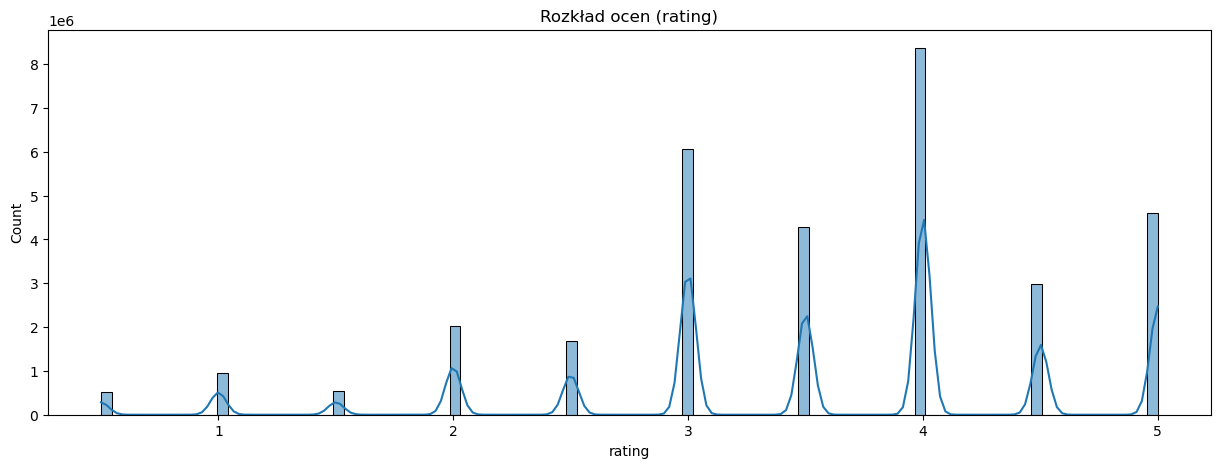

In [8]:
import seaborn as sns
plt.figure(figsize=(15, 5))
sns.histplot(ratings["rating"], bins=100, kde=True)
plt.title("Rozkład ocen (rating)")

In [9]:
print(ratings["userId"].nunique())
print(ratings["movieId"].nunique())

200948
84432


In [10]:
# sprawdzamy gęstość macierzy i wartośći puste
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)

sparsity = 1 - (n_ratings / (n_users * n_movies))
print(f"Sparsity: {sparsity:.6f}")
print(f"Density: {(1 - sparsity):.6f}")

Sparsity: 0.998114
Density: 0.001886


In [11]:
user_ids = ratings["userId"].unique()
movie_ids = ratings["movieId"].unique()

user_mapper = {user_id: i for i, user_id in enumerate(user_ids)}
movie_mapper = {movie_id: i for i, movie_id in enumerate(movie_ids)}

In [12]:
user_index = ratings["userId"].map(user_mapper)
movie_index = ratings["movieId"].map(movie_mapper)

In [13]:
import scipy.sparse as sp
csr_user_item = sp.csr_matrix((ratings["rating"], (user_index, movie_index)), shape=(n_users, n_movies))
csr_user_item.shape

(200948, 84432)

In [14]:
csr_item_user = csr_user_item.T

In [15]:
csr_user_item.nnz

32000204

In [16]:
# csr_test.shape # liczba wierszy i kolumn
# csr_test.nnz # liczba niezerowych elementów
# csr_test.T # transpozycja macierzy
# csr_test.toarray() # konwersja do gęstej macierzy (niezalecane dla dużych zbiorów danych)
# csr_test.getrow(0) # pobranie wiersza o indeksie 0
# csr_test.getcol(0) # pobranie kolumny o indeksie 0

In [17]:
ratings_sorted = ratings.sort_values(by=["userId", "timestamp"], ascending=True)

In [18]:
ratings_sorted.head(10)

,userId,movieId,rating,timestamp
134,1,2966,1.0,943226846
137,1,2997,4.0,943226846
131,1,2890,4.0,943226916
139,1,3078,2.0,943226986
130,1,2882,1.0,943227458
23,1,541,5.0,943227521
30,1,838,5.0,943227632
48,1,1136,1.0,943228327
61,1,1211,2.0,943228400
69,1,1236,4.0,943228400


In [19]:
ratings_test = ratings_sorted.groupby("userId").tail(1)
ratings_test

,userId,movieId,rating,timestamp
107,1,2125,4.0,944256398
192,2,783,5.0,836424241
295,3,3248,4.0,1084486164
349,4,2600,2.0,960485723
390,5,410,3.0,840768897
...,...,...,...,...
31999636,200944,69122,3.5,1454856831
31999809,200945,2571,3.0,1520792556
31999900,200946,589,4.0,845271609
31999967,200947,164909,4.5,1495973775


In [20]:
ratings_train = ratings_sorted.drop(ratings_test.index)
ratings_train

,userId,movieId,rating,timestamp
134,1,2966,1.0,943226846
137,1,2997,4.0,943226846
131,1,2890,4.0,943226916
139,1,3078,2.0,943226986
130,1,2882,1.0,943227458
...,...,...,...,...
32000082,200948,3745,4.5,1350423588
32000066,200948,2710,4.0,1350423730
32000194,200948,72011,4.5,1350423792
32000202,200948,80463,3.5,1350423800


In [21]:
ratings_test["userId"].unique().shape

(200948,)

In [22]:
ratings_train["userId"].unique().shape

(200948,)

In [23]:
ratings_test["movieId"].unique().shape

(13600,)

In [24]:
ratings_train["movieId"].unique().shape

(84333,)

In [25]:
set_test_movies = set(ratings_test["movieId"])
set_train_movies = set(ratings_train["movieId"])

In [26]:
compare_movies = set_test_movies - set_train_movies
len(compare_movies)

99

In [27]:
train_movies = set(ratings_train["movieId"])
ratings_test = ratings_test[ratings_test["movieId"].isin(train_movies)]

In [28]:
ratings_sorted.describe(include="all")

,userId,movieId,rating,timestamp
count,3.200020e+07,3.200020e+07,3.200020e+07,3.200020e+07
mean,1.002785e+05,2.931861e+04,3.540396e+00,1.275241e+09
std,5.794905e+04,5.095816e+04,1.058986e+00,2.561630e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,5.005300e+04,1.233000e+03,3.000000e+00,1.051012e+09
50%,1.002970e+05,3.452000e+03,3.500000e+00,1.272622e+09
75%,1.504510e+05,4.419900e+04,4.000000e+00,1.503158e+09
max,2.009480e+05,2.927570e+05,5.000000e+00,1.697164e+09


In [29]:
ratings_per_user = ratings.groupby("userId").size()
ratings_per_user

userId
1         141
2          52
3         147
4          27
5          33
         ... 
200944    298
200945    108
200946     23
200947     61
200948    236
Length: 200948, dtype: int64

In [30]:
ratings_per_user.min()

np.int64(20)

In [31]:
print("Users in train:", ratings_train["userId"].nunique())
print("Users in test after filtering:", ratings_test["userId"].nunique())
print("Rows in test after filtering:", len(ratings_test))
print("Min test rows per user:", ratings_test.groupby("userId").size().min())
print("Max test rows per user:", ratings_test.groupby("userId").size().max())

Users in train: 200948
Users in test after filtering: 200848
Rows in test after filtering: 200848
Min test rows per user: 1
Max test rows per user: 1


In [32]:
train_users = set(ratings_train["userId"])
test_users = set(ratings_test["userId"])

missing_test_users = train_users - test_users
len(missing_test_users)

100

In [33]:
print(ratings_train["userId"].min())
print(ratings_train["userId"].max())
print(ratings_test["userId"].min())
print(ratings_test["userId"].max())
print(ratings_train["userId"].unique().shape)
print(ratings_test["userId"].unique().shape)

1
200948
1
200948
(200948,)
(200848,)


In [34]:
ids = np.sort(ratings_train["userId"].unique())
np.all(ids == np.arange(ids.min(), ids.max()+1))

np.True_

In [35]:
ratings_train.head()

,userId,movieId,rating,timestamp
134,1,2966,1.0,943226846
137,1,2997,4.0,943226846
131,1,2890,4.0,943226916
139,1,3078,2.0,943226986
130,1,2882,1.0,943227458


In [36]:
ratings_test.head()

,userId,movieId,rating,timestamp
107,1,2125,4.0,944256398
192,2,783,5.0,836424241
295,3,3248,4.0,1084486164
349,4,2600,2.0,960485723
390,5,410,3.0,840768897


In [37]:
ratings_train["movieId"].unique().shape

(84333,)

In [38]:
ratings_train.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [39]:
ratings_train.shape

(31799256, 4)

In [40]:
len(ratings_train)

31799256

In [41]:
ratings_train["userId"].unique().shape

(200948,)

In [42]:
ratings_train["movieId"].unique().shape

(84333,)

In [43]:
user_unique = ratings_train["userId"].unique()
user_unique
len(user_unique)

200948

In [44]:
movie_unique = ratings_train["movieId"].unique()
movie_unique
len(movie_unique)

84333

In [45]:
dict_user = {user_id: i for i, user_id in enumerate(user_unique)}
# dict_user

In [46]:
dict_movie = {movie_id: i for i, movie_id in enumerate(movie_unique)}
# dict_movie

In [47]:
user_item_csr = sp.csr_matrix((ratings_train["rating"], (ratings_train["userId"].map(dict_user), ratings_train["movieId"].map(dict_movie))), shape=(len(user_unique), len(movie_unique)))
user_item_csr.shape

(200948, 84333)

In [48]:
user_item_csr.nnz

31799256

In [49]:
type(user_item_csr)

scipy.sparse._csr.csr_matrix

In [50]:
user_item_csr[0].indices, user_item_csr[0].data

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139], dtype=int32),
 array([1., 4., 4., 2., 1., 5., 5., 1., 2., 4., 5., 4., 4., 5., 5., 1., 2.,
        2., 1., 4., 1., 3., 5., 1., 5., 5., 5., 3., 5., 3., 5., 5., 2., 2.,
        2., 4., 5., 5., 3., 2., 3., 2., 4., 2

In [51]:
for i in range(5):
    row = user_item_csr[i]
    order = np.argsort(row.data)[::-1]

    top_movies = row.indices[order][:10]
    top_ratings = row.data[order][:10]

    print("User:", i)
    print("Movies:", top_movies)
    print("Ratings:", top_ratings)

User: 0
Movies: [139 137 128 135 129 117 113 121 122 125]
Ratings: [5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]
User: 1
Movies: [188 187 185 170 178 179 181 176 174 177]
Ratings: [5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]
User: 2
Movies: [296 291 290 292 285 205  38 106 196  40]
Ratings: [5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]
User: 3
Movies: [300 317  56  86 305 311 310 315 309 299]
Ratings: [5. 4. 4. 4. 4. 4. 3. 3. 3. 3.]
User: 4
Movies: [156 142 212 319 153 157 203 216  39 140]
Ratings: [5. 5. 4. 4. 4. 4. 4. 4. 4. 4.]


In [52]:
ratings_train.groupby("movieId").size()


movieId
1         68600
2         28743
3         13041
4          2786
5         13087
          ...  
292625        1
292627        1
292709        1
292731        1
292737        1
Length: 84333, dtype: int64

In [53]:
ratings_train.groupby("movieId")["rating"].count()

movieId
1         68600
2         28743
3         13041
4          2786
5         13087
          ...  
292625        1
292627        1
292709        1
292731        1
292737        1
Name: rating, Length: 84333, dtype: int64

In [54]:
top_movies = ratings_train.groupby("movieId").size().sort_values(ascending=False)
top_movies.head(10)
type(top_movies)
type(ratings_train)

pandas.core.frame.DataFrame

In [55]:
user_id = ratings_train["userId"].iloc[0]

In [56]:
user_movies = ratings_train[ratings_train["userId"] == user_id]["movieId"]
user_movies

134    2966
137    2997
131    2890
139    3078
130    2882
       ... 
115    2329
127    2712
37      926
83     1392
101    2020
Name: movieId, Length: 140, dtype: int64

In [57]:
ratings_train.head(20)

,userId,movieId,rating,timestamp
134,1,2966,1.0,943226846
137,1,2997,4.0,943226846
131,1,2890,4.0,943226916
139,1,3078,2.0,943226986
130,1,2882,1.0,943227458
23,1,541,5.0,943227521
30,1,838,5.0,943227632
48,1,1136,1.0,943228327
61,1,1211,2.0,943228400
69,1,1236,4.0,943228400


In [58]:
top_movies_filtered = top_movies[~top_movies.index.isin(user_movies)]
top_movies_filtered.head(10)

movieId
318     102348
296      97856
2571     93274
2959     76790
480      74684
4993     72753
1        68600
589      67774
50       67240
7153     67169
dtype: int64

In [59]:
top_df = top_movies_filtered.head(10).reset_index()
top_df.columns = ["movieId", "count"]
type(top_df)
top_df.head(10)

,movieId,count
0,318,102348
1,296,97856
2,2571,93274
3,2959,76790
4,480,74684
5,4993,72753
6,1,68600
7,589,67774
8,50,67240
9,7153,67169


In [60]:
top_df = top_df.merge(movies, on="movieId", how="left")
type(top_df)
top_df.head(10)

,movieId,count,title,genres
0,318,102348,"Shawshank Redemption, The (1994)",Crime|Drama
1,296,97856,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
2,2571,93274,"Matrix, The (1999)",Action|Sci-Fi|Thriller
3,2959,76790,Fight Club (1999),Action|Crime|Drama|Thriller
4,480,74684,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
5,4993,72753,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy
6,1,68600,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
7,589,67774,Terminator 2: Judgment Day (1991),Action|Sci-Fi
8,50,67240,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
9,7153,67169,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy


In [61]:
top_df[["title", "count"]]

,title,count
0,"Shawshank Redemption, The (1994)",102348
1,Pulp Fiction (1994),97856
2,"Matrix, The (1999)",93274
3,Fight Club (1999),76790
4,Jurassic Park (1993),74684
5,"Lord of the Rings: The Fellowship of the Ring,...",72753
6,Toy Story (1995),68600
7,Terminator 2: Judgment Day (1991),67774
8,"Usual Suspects, The (1995)",67240
9,"Lord of the Rings: The Return of the King, The...",67169


In [62]:
top_df_inner = top_df.merge(movies, on="movieId", how="inner")
top_df_inner.head(10)

,movieId,count,title_x,genres_x,title_y,genres_y
0,318,102348,"Shawshank Redemption, The (1994)",Crime|Drama,"Shawshank Redemption, The (1994)",Crime|Drama
1,296,97856,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
2,2571,93274,"Matrix, The (1999)",Action|Sci-Fi|Thriller,"Matrix, The (1999)",Action|Sci-Fi|Thriller
3,2959,76790,Fight Club (1999),Action|Crime|Drama|Thriller,Fight Club (1999),Action|Crime|Drama|Thriller
4,480,74684,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
5,4993,72753,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy
6,1,68600,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
7,589,67774,Terminator 2: Judgment Day (1991),Action|Sci-Fi,Terminator 2: Judgment Day (1991),Action|Sci-Fi
8,50,67240,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
9,7153,67169,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy


In [63]:
top_df = top_movies_filtered.head(10).rename("count").reset_index()
top_df = top_df.merge(movies[["movieId", "title"]], on="movieId", how="left")
top_df

,movieId,count,title
0,318,102348,"Shawshank Redemption, The (1994)"
1,296,97856,Pulp Fiction (1994)
2,2571,93274,"Matrix, The (1999)"
3,2959,76790,Fight Club (1999)
4,480,74684,Jurassic Park (1993)
5,4993,72753,"Lord of the Rings: The Fellowship of the Ring,..."
6,1,68600,Toy Story (1995)
7,589,67774,Terminator 2: Judgment Day (1991)
8,50,67240,"Usual Suspects, The (1995)"
9,7153,67169,"Lord of the Rings: The Return of the King, The..."


In [64]:
top_df["title"] = top_df["movieId"].map(movies.set_index("movieId")["title"])

In [108]:
item_user_csr = user_item_csr.T
item_user_csr.shape

(84333, 200948)

In [110]:
movie_idx = 137

In [111]:
movie_vector = item_user_csr[movie_idx]
movie_vector.toarray()

array([[5., 0., 0., ..., 0., 0., 0.]], shape=(1, 200948))

In [112]:
movie_vector.indices   # userzy
movie_vector.data      # oceny

array([5. , 3. , 4. , ..., 4.5, 4. , 3. ], shape=(6032,))

In [113]:
from sklearn.metrics.pairwise import cosine_similarity

In [114]:
similarities = cosine_similarity(movie_vector, item_user_csr)

In [115]:
similarities = similarities.flatten()

In [116]:
type(similarities)

numpy.ndarray

In [117]:
similarities[movie_idx] = 0

In [118]:
top_indices = similarities.argsort()[::-1][:10]

In [119]:
inv_movie_dict = {v: k for k, v in dict_movie.items()}
top_movie_ids = [inv_movie_dict[i] for i in top_indices]

In [120]:
recommended = movies[movies["movieId"].isin(top_movie_ids)]
recommended

,movieId,title,genres
877,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance
884,905,It Happened One Night (1934),Comedy|Romance
888,909,"Apartment, The (1960)",Comedy|Drama|Romance
889,910,Some Like It Hot (1959),Comedy|Crime
901,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance
907,928,Rebecca (1940),Drama|Mystery|Romance|Thriller
909,930,Notorious (1946),Film-Noir|Romance|Thriller
930,951,His Girl Friday (1940),Comedy|Romance
1077,1104,"Streetcar Named Desire, A (1951)",Drama
1856,1945,On the Waterfront (1954),Crime|Drama


In [121]:
recommended["score"] = recommended["movieId"].map(
    {inv_movie_dict[i]: similarities[i] for i in top_indices}
)

recommended = recommended.sort_values("score", ascending=False)
recommended

C:\Users\kbron\AppData\Local\Temp\ipykernel_25052\1834496371.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recommended["score"] = recommended["movieId"].map(


,movieId,title,genres,score
901,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,0.453266
907,928,Rebecca (1940),Drama|Mystery|Romance|Thriller,0.406321
888,909,"Apartment, The (1960)",Comedy|Drama|Romance,0.402140
884,905,It Happened One Night (1934),Comedy|Romance,0.402013
1077,1104,"Streetcar Named Desire, A (1951)",Drama,0.388957
909,930,Notorious (1946),Film-Noir|Romance|Thriller,0.388813
877,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,0.383058
889,910,Some Like It Hot (1959),Comedy|Crime,0.382209
930,951,His Girl Friday (1940),Comedy|Romance,0.378782
1856,1945,On the Waterfront (1954),Crime|Drama,0.374049


In [122]:
user_ratings = ratings_train[ratings_train["userId"] == user_id]

In [123]:
user_top_ratings = user_ratings.sort_values("rating", ascending=False)

In [124]:
user_top_10 = user_top_ratings.head(20)

In [125]:
user_top_10 = user_top_10.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
)

In [126]:
user_top_10 = (
    ratings_train[ratings_train["userId"] == user_id]
    .sort_values(["rating", "timestamp"], ascending=[False, False])
    .head(10)
    .merge(movies[["movieId", "title", "genres"]], on="movieId", how="left")
)

user_top_10[["movieId", "title", "genres", "rating", "timestamp"]].sort_values(["rating", "timestamp"], ascending=[False, False])

,movieId,title,genres,rating,timestamp
0,926,All About Eve (1950),Drama,5.0,944256398
1,2020,Dangerous Liaisons (1988),Drama|Romance,5.0,944256398
2,2329,American History X (1998),Crime|Drama,5.0,944253272
3,307,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama,5.0,944253207
4,1056,Jude (1996),Drama,5.0,944253207
5,1228,Raging Bull (1980),Drama,5.0,944253207
6,2313,"Elephant Man, The (1980)",Drama,5.0,944253207
7,1041,Secrets & Lies (1996),Drama,5.0,944253134
8,1693,Amistad (1997),Drama|Mystery,5.0,944253134
9,908,North by Northwest (1959),Action|Adventure|Mystery|Romance|Thriller,5.0,944250228


In [127]:
recommended

,movieId,title,genres,score
901,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,0.453266
907,928,Rebecca (1940),Drama|Mystery|Romance|Thriller,0.406321
888,909,"Apartment, The (1960)",Comedy|Drama|Romance,0.402140
884,905,It Happened One Night (1934),Comedy|Romance,0.402013
1077,1104,"Streetcar Named Desire, A (1951)",Drama,0.388957
909,930,Notorious (1946),Film-Noir|Romance|Thriller,0.388813
877,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,0.383058
889,910,Some Like It Hot (1959),Comedy|Crime,0.382209
930,951,His Girl Friday (1940),Comedy|Romance,0.378782
1856,1945,On the Waterfront (1954),Crime|Drama,0.374049


In [128]:
user_ratings = ratings_train[ratings_train["userId"] == user_id]

user_top_10 = user_ratings.sort_values(
    ["rating", "timestamp"],
    ascending=[False, False]
).head(10)

user_top_10 = user_top_10.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
)

user_top_10["date"] = pd.to_datetime(user_top_10["timestamp"], unit="s")

user_top_10[["movieId", "title", "genres", "rating", "date"]]

,movieId,title,genres,rating,date
0,926,All About Eve (1950),Drama,5.0,1999-12-03 21:26:38
1,2020,Dangerous Liaisons (1988),Drama|Romance,5.0,1999-12-03 21:26:38
2,2329,American History X (1998),Crime|Drama,5.0,1999-12-03 20:34:32
3,307,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama,5.0,1999-12-03 20:33:27
4,1056,Jude (1996),Drama,5.0,1999-12-03 20:33:27
5,1228,Raging Bull (1980),Drama,5.0,1999-12-03 20:33:27
6,2313,"Elephant Man, The (1980)",Drama,5.0,1999-12-03 20:33:27
7,1041,Secrets & Lies (1996),Drama,5.0,1999-12-03 20:32:14
8,1693,Amistad (1997),Drama|Mystery,5.0,1999-12-03 20:32:14
9,908,North by Northwest (1959),Action|Adventure|Mystery|Romance|Thriller,5.0,1999-12-03 19:43:48


In [129]:
user_top_10.iloc[0]

userId                          1
movieId                       926
rating                        5.0
timestamp               944256398
title        All About Eve (1950)
genres                      Drama
date          1999-12-03 21:26:38
Name: 0, dtype: object

In [130]:
top_movie_this_user = movies[movies["movieId"] == 926]
top_movie_this_user

,movieId,title,genres
905,926,All About Eve (1950),Drama


In [131]:
inv_dict_movie = {v: k for k, v in dict_movie.items()}

In [132]:
inv_dict_movie[926]

np.int64(168252)

In [255]:
for k, v in inv_dict_movie.items():
    if v == 4993:
        print(k, v)

338 4993


In [139]:
type(movies)

pandas.core.frame.DataFrame

In [141]:
chosen_list = [it for it in movies["title"] if "It" in it]

In [143]:
len(chosen_list)

647

In [145]:
chosen_list = [(mid, title) for mid, title in movies[["movieId", "title"]].values if "It (" in title]

In [146]:
len(chosen_list)

104

In [148]:
chosen_list = movies[movies["title"].str.contains("It \\(")]

In [151]:
chosen_list[chosen_list["genres"] == "Horror"]

,movieId,title,genres
48313,175303,It (2017),Horror
82231,276371,Ignore It (2021),Horror


In [152]:
for k, v in inv_dict_movie.items():
    if v == 175303:
        print(k, v)

3336 175303


In [256]:
movie_idx = 338

In [257]:
movie_vector = item_user_csr[movie_idx]

In [260]:
movie_vector

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 72753 stored elements and shape (1, 200948)>

In [261]:
movie_vector.shape

(1, 200948)

In [262]:
scores = cosine_similarity(movie_vector, item_user_csr)

In [263]:
scores = scores.flatten()

In [264]:
scores

array([0.13475439, 0.38399195, 0.25283228, ..., 0.        , 0.0035185 ,
       0.0035185 ], shape=(84333,))

In [265]:
recommended = [(idx, score) for idx, score in enumerate(scores) if idx != movie_idx]

In [266]:
len(recommended)

84332

In [267]:
recommended.sort(key=lambda x: x[1], reverse=True)

In [268]:
recommended[:10]

[(421, np.float64(0.8858159792826523)),
 (420, np.float64(0.8726032295964014)),
 (569, np.float64(0.6865080878980179)),
 (284, np.float64(0.636472520362545)),
 (192, np.float64(0.6254937586762389)),
 (351, np.float64(0.616005627285929)),
 (272, np.float64(0.615609720203027)),
 (358, np.float64(0.5985315501008542)),
 (26, np.float64(0.598209109906236)),
 (739, np.float64(0.5841555938374334))]

In [269]:
recommended_final = [(inv_dict_movie[idx], score) for idx, score in recommended[:20]]

In [270]:
recommended_df = pd.DataFrame(recommended_final, columns=["movieId", "score"])

In [271]:
chosen_list[chosen_list["genres"] == "Horror"]

,movieId,title,genres


In [272]:
recommended_df.merge(movies, on="movieId", how="left")

,movieId,score,title,genres
0,5952,0.885816,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy
1,7153,0.872603,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy
2,2571,0.686508,"Matrix, The (1999)",Action|Sci-Fi|Thriller
3,6539,0.636473,Pirates of the Caribbean: The Curse of the Bla...,Action|Adventure|Comedy|Fantasy
4,4306,0.625494,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...
5,2959,0.616006,Fight Club (1999),Action|Crime|Drama|Thriller
6,3578,0.615610,Gladiator (2000),Action|Adventure|Drama
7,58559,0.598532,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX
8,1196,0.598209,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi
9,33794,0.584156,Batman Begins (2005),Action|Crime|IMAX


In [254]:
movies[movies["title"].str.contains("Lord of the Rings")]

,movieId,title,genres
2026,2116,"Lord of the Rings, The (1978)",Adventure|Animation|Children|Fantasy
4888,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy
5841,5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy
7029,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy
71797,231829,A Passage to Middle-earth: Making of 'Lord of ...,Documentary
79743,267392,"J.R.R. Tolkien and the Birth Of ""The Lord of t...",(no genres listed)


In [191]:
movies[movies["title"].str.contains("Witcher")]

,movieId,title,genres
39891,157379,Witchery (1988),Horror
77370,257595,The Witcher: Nightmare of the Wolf (2021),Action|Animation|Fantasy
